## Library

In [1]:
from wass2s import *
import datetime
import importlib
from pathlib import Path
import warnings
import gc
warnings.filterwarnings("ignore")

#### Set forecast working directory

In [2]:
# Set forecast working directory
dir_s2s = "./PRCP_JAS_2024_ic_4/"
logopath = './utilities/cilss.png'#'./utilities/agrhymet_logo_combined_reversed.png'
fcst_labels = ["BELOW-AVERAGE", "NEAR-AVERAGE", "ABOVE-AVERAGE"]#["EN DESSOUS DE LA MOYENNE", "PROCHE DE LA MOYENNE", "AU DESSUS DE LA MOYENNE"]
dist_method="bestfit" # nonparam or bestfit

In [3]:
dir_s2s = Path(dir_s2s)
os.makedirs(dir_s2s, exist_ok=True)
### Save consolidated results
hdcst_consolidated = {}
hdcst_consolidated_prob = {}
fcst_consolidated = {}
fcst_consolidated_prob = {}
scores_consolidated = {}
### Save score
dir_save_score = f"{dir_s2s}/scores"
os.makedirs(dir_save_score, exist_ok=True)
### Save forecasts
dir_to_forecast = f"{dir_s2s}/forecasts"
os.makedirs(dir_to_forecast, exist_ok=True)

#### Set Climatological Years

In [4]:
# Set Climatological Years
clim_year_start = 1994 #1991
clim_year_end = 2016 #2020

## Download Observation and Process 


#### Load Downloader 

In [5]:
# Load WAS_S2S downloader class
downloader = WAS_Download()

In [6]:
# Filter observation names to identify precipitation-related models
variables_obs = [key for key in downloader.AgroObsName().keys() if "PRCP" in key]

# Specify the directory to save downloaded model data
dir_to_save_Obs = f"{dir_s2s}/Observation"

# choose sequence corresponding to seasonal forecast targets (JAS season in this case)
season_obs = ["07", "08", "09"]  # July-August-September forecast period

# Define the observation period (years 1993 to 2016)
year_start = 1991
year_end = 2023

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent_obs = [21, -26, 4, 25]  # [Northern, Western, Southern and Eastern] 

# Specify whether to overwrite existing files when downloading data
force_download = False

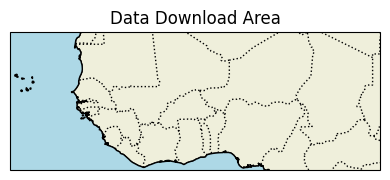

In [7]:
plot_map([extent_obs[1],extent_obs[3],extent_obs[2],extent_obs[0]], title="Data Download Area", fig_size=(4,3))

In [8]:
downloader.WAS_Download_AgroIndicators(
    dir_to_save_Obs,
    variables_obs,
    year_start,
    year_end,
    extent_obs,
    season_obs,
    force_download
)

PRCP_JAS_2024_ic_4/Observation/Obs_PRCP_1991_2023_JulAugSep.nc already exists. Skipping download.


In [9]:
#### Process predictant
rainfall = prepare_predictand(dir_to_save_Obs, variables_obs, year_start, year_end, season_obs, ds=False, daily=False)
season_str = "".join([calendar.month_abbr[int(month)] for month in season_obs])

#### Process Obs in combining with Seasonal cumulative Ground-Observation

In [11]:
# ## Path to the CPT file
cpt_input_file_path = "./PRCP_JAS_2024_ic_4/JAS_REGIONAL.csv"

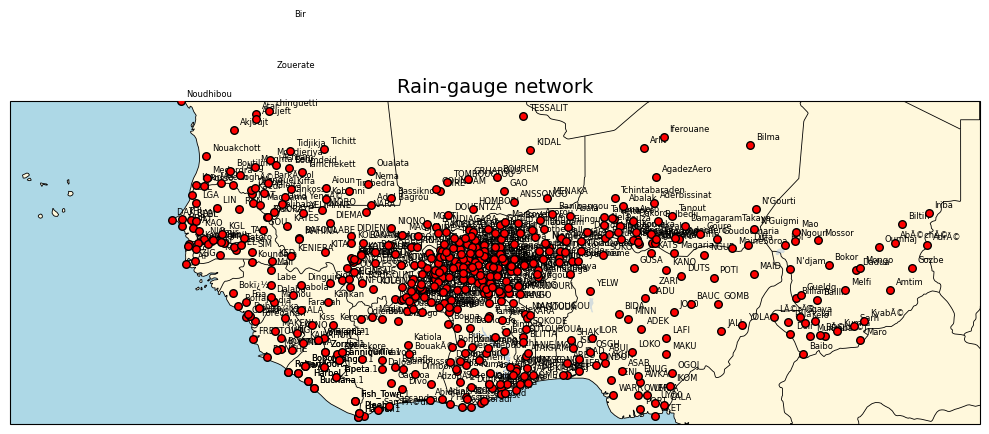

In [12]:
# ## Read CSV
df = pd.read_csv(cpt_input_file_path, na_values=-999.0,  encoding="latin1")
df_filtered = df[(df['STATION'] == 'LAT') | (df['STATION'] == 'LON') | 
                 (pd.to_numeric(df['STATION'], errors='coerce').between(year_start, year_end))]
verify_station_network(df_filtered, extent_obs)

In [13]:
da = prepare_predictand(dir_to_save_Obs, variables_obs, year_start, year_end, season_obs,  ds=False).sel(T=slice(str(year_start),str(year_end)))

In [14]:
### ## Instantiate WAS_Merging class
path_ = Path(dir_s2s / "rainfall_predictand.nc")
data_merger = WAS_Merging(df_filtered, da, date_month_day= '08-01')
if path_.is_file():
    rainfall__ = xr.load_dataarray(path_)
else:
    rainfall__, _ = data_merger.simple_bias_adjustment(do_cross_validation=False)
    rainfall__.to_netcdf(path_)

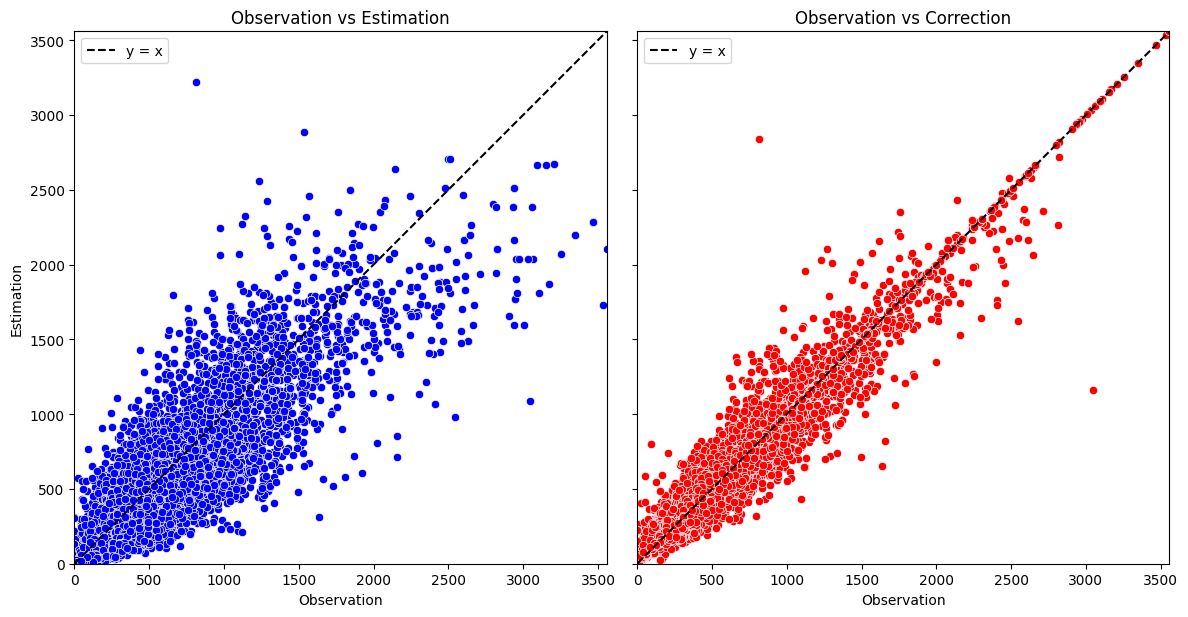

In [15]:
data_merger.plot_merging_comparaison(df_filtered, da, rainfall__)

In [16]:
rainfall = rainfall__
rainfall.name = "PRCP"

#### Identify the parametric distribution that best fits the observations

In [10]:
if dist_method=="nonparam":
    pass
else:
    transf = WAS_TransformData(rainfall.sel(T=slice(str(clim_year_start),str(clim_year_end))), 
                      distribution_map={'norm': 1, 'lognorm': 2, 'gamma': 4,}, #'norm': 1, 'lognorm': 2, 'expon': 3, 'gamma': 4, 'weibull_min': 5, 't_dist': 6, "poisson":7, "nbinom":8 
                                n_clusters=1000)
    best_code_da, best_shape_da, best_loc_da, best_scale_da, _ = transf.fit_best_distribution(mode="grid")

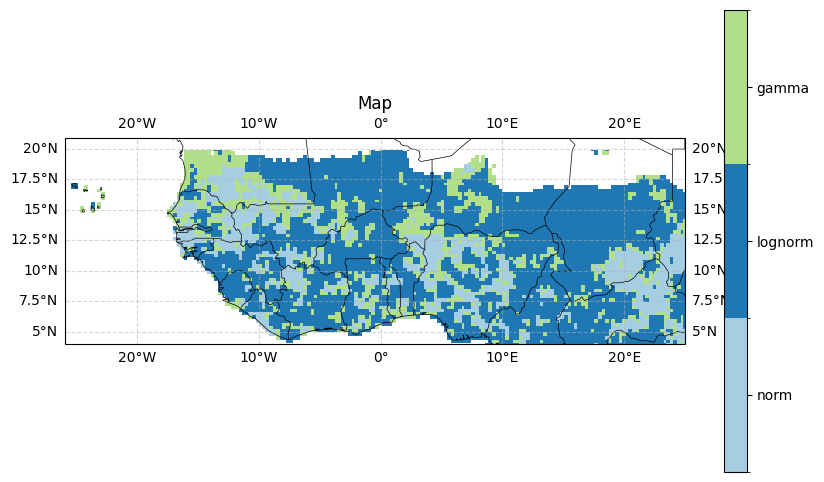

In [11]:
if dist_method=="bestfit":
    transf.plot_best_fit_map(best_code_da,
                             {'norm': 1, 'lognorm': 2, 'expon': 3, 'gamma': 4,
                              'weibull_min': 5, 't_dist': 6, "poisson":7, "nbinom":8},
                             show_plot=True)

# 1st - Approach: Skill-Verified, Machine Learning–Calibrated Multi-Model Ensemble (SV-ML-CMME)

In [19]:
# Filter model names to identify precipitation-related models
center_variable = [key for key in downloader.ModelsName().keys() if "PRCP" in key]
# center_variable.remove('UKMO_603.PRCP')
# center_variable.remove('DWD_21.PRCP')
# center_variable.remove('METEOFRANCE_8.PRCP')
# Specify the directory to save downloaded model data
dir_to_save_model = f"{dir_s2s}/model_data"

# Define the month for model initialization (June)
month_of_initialization = "04"

# Define lead times corresponding to seasonal forecast targets (JAS season in this case)
lead_time = ["03", "04", "05"]  # July-August-September forecast period

# Define the hindcast period for model data (years 1993 to 2016)
year_start_model = 1993
year_end_model = 2016

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent = [21, -26, 4, 25] # [Northern, Western, Southern and Eastern] 

# Define if you want to download forecast or hindcast
forecast = None

# Define if you want all members of ensemble or doing an ensemble mean
ensemble_mean = "mean"

# Specify whether to overwrite existing files when downloading data
force_download = False

In [20]:
hindcast_files = downloader.WAS_Download_Models(
    dir_to_save_model,
    center_variable,
    month_of_initialization,
    lead_time,
    year_start_model,
    year_end_model,
    extent, 
    forecast,
    ensemble_mean,
    force_download)

PRCP_JAS_2024_ic_4/model_data/hindcast_bom2_PRCP_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/hindcast_ecmwf51_PRCP_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/hindcast_ukmo604_PRCP_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/hindcast_ukmo603_PRCP_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/hindcast_meteofrance8_PRCP_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/hindcast_meteofrance9_PRCP_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/hindcast_dwd21_PRCP_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/hindcast_dwd22_PRCP_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/hindcast_cmcc35_PRCP_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_

In [21]:
forecast = 2024

In [22]:
forecast_files = downloader.WAS_Download_Models(
    dir_to_save_model,
    center_variable,
    month_of_initialization,
    lead_time,
    year_start_model,
    year_end_model,
    extent, 
    forecast,
    ensemble_mean,
    force_download)

2026-02-05 06:46:27,095 INFO Request ID is a45ffb2e-159d-44a8-bcde-b2c63fcbab13
2026-02-05 06:46:27,402 INFO status has been updated to accepted
2026-02-05 06:46:42,957 INFO status has been updated to running
2026-02-05 06:47:02,779 INFO status has been updated to failed


Failed to download data for PRCP: 400 Client Error: Bad Request for url: https://cds.climate.copernicus.eu/api/retrieve/v1/jobs/a45ffb2e-159d-44a8-bcde-b2c63fcbab13/results
The job has failed
MARS returned no data, please check your selection.Request submitted to the MARS server:
[{'area': ['21', '-26', '4', '25'], 'fcmonth': ['03', '04', '05'], 'origin': ['ammc'], 'type': ['fcmean'], 'system': ['2'], 'param': ['172228'], 'time': ['all'], 'class': ['c3'], 'expect': ['any'], 'expver': ['1'], 'method': ['1'], 'number': ['all'], 'stream': ['msmm'], 'levtype': ['sfc'], 'database': 'ecmwf', 'date': ['2024-04-01']}]

The job failed with: MarsNoDataError
PRCP_JAS_2024_ic_4/model_data/forecast_ecmwf51_PRCP_AprIc_JulAugSep_03.nc already exists. Skipping download.


2026-02-05 06:47:04,986 INFO Request ID is 77cae646-df92-4d35-91cb-dcf6e91fa087
2026-02-05 06:47:05,471 INFO status has been updated to accepted
2026-02-05 06:47:28,072 INFO status has been updated to running
2026-02-05 06:47:39,755 INFO status has been updated to failed


Failed to download data for PRCP: 400 Client Error: Bad Request for url: https://cds.climate.copernicus.eu/api/retrieve/v1/jobs/77cae646-df92-4d35-91cb-dcf6e91fa087/results
The job has failed
MARS returned no data, please check your selection.Request submitted to the MARS server:
[{'area': ['21', '-26', '4', '25'], 'fcmonth': ['03', '04', '05'], 'origin': ['egrr'], 'type': ['fcmean'], 'system': ['604'], 'param': ['172228'], 'time': ['all'], 'class': ['c3'], 'expect': ['any'], 'expver': ['1'], 'method': ['1'], 'number': ['all'], 'stream': ['msmm'], 'levtype': ['sfc'], 'database': 'ecmwf', 'date': ['2024-04-01']}]

The job failed with: MarsNoDataError
PRCP_JAS_2024_ic_4/model_data/forecast_ukmo603_PRCP_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/forecast_meteofrance8_PRCP_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/forecast_meteofrance9_PRCP_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_

2026-02-05 06:47:42,190 INFO Request ID is 536d381f-dfea-4681-bc2f-de1359e22225
2026-02-05 06:47:42,413 INFO status has been updated to accepted
2026-02-05 06:47:57,098 INFO status has been updated to running
2026-02-05 06:48:04,890 INFO status has been updated to failed


Failed to download data for PRCP: 400 Client Error: Bad Request for url: https://cds.climate.copernicus.eu/api/retrieve/v1/jobs/536d381f-dfea-4681-bc2f-de1359e22225/results
The job has failed
MARS returned no data, please check your selection.Request submitted to the MARS server:
[{'area': ['21', '-26', '4', '25'], 'fcmonth': ['03', '04', '05'], 'origin': ['edzw'], 'type': ['fcmean'], 'system': ['22'], 'param': ['172228'], 'time': ['all'], 'class': ['c3'], 'expect': ['any'], 'expver': ['1'], 'method': ['1'], 'number': ['all'], 'stream': ['msmm'], 'levtype': ['sfc'], 'database': 'ecmwf', 'date': ['2024-04-01']}]

The job failed with: MarsNoDataError
PRCP_JAS_2024_ic_4/model_data/forecast_cmcc35_PRCP_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/forecast_ncep2_PRCP_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/forecast_jma3_PRCP_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/mod

In [23]:
hindcast_files = {k: hindcast_files[k] for k in hindcast_files.keys() & forecast_files.keys()}
forecast_files = {k: forecast_files[k] for k in hindcast_files.keys() & forecast_files.keys()}
common_keys = {k.lower() for k in hindcast_files} & {k.lower() for k in forecast_files}
center_variable = [
    item
    for item in center_variable
    if any(item.lower().startswith(k) for k in list(common_keys))
                ]

In [12]:
was_verify = WAS_Verification(dist_method=dist_method, mae_rmse_crps_thrsd=500)

#### Validation of GCM

In [25]:
score = ["Pearson", "MAE"]

Pearson Correlation


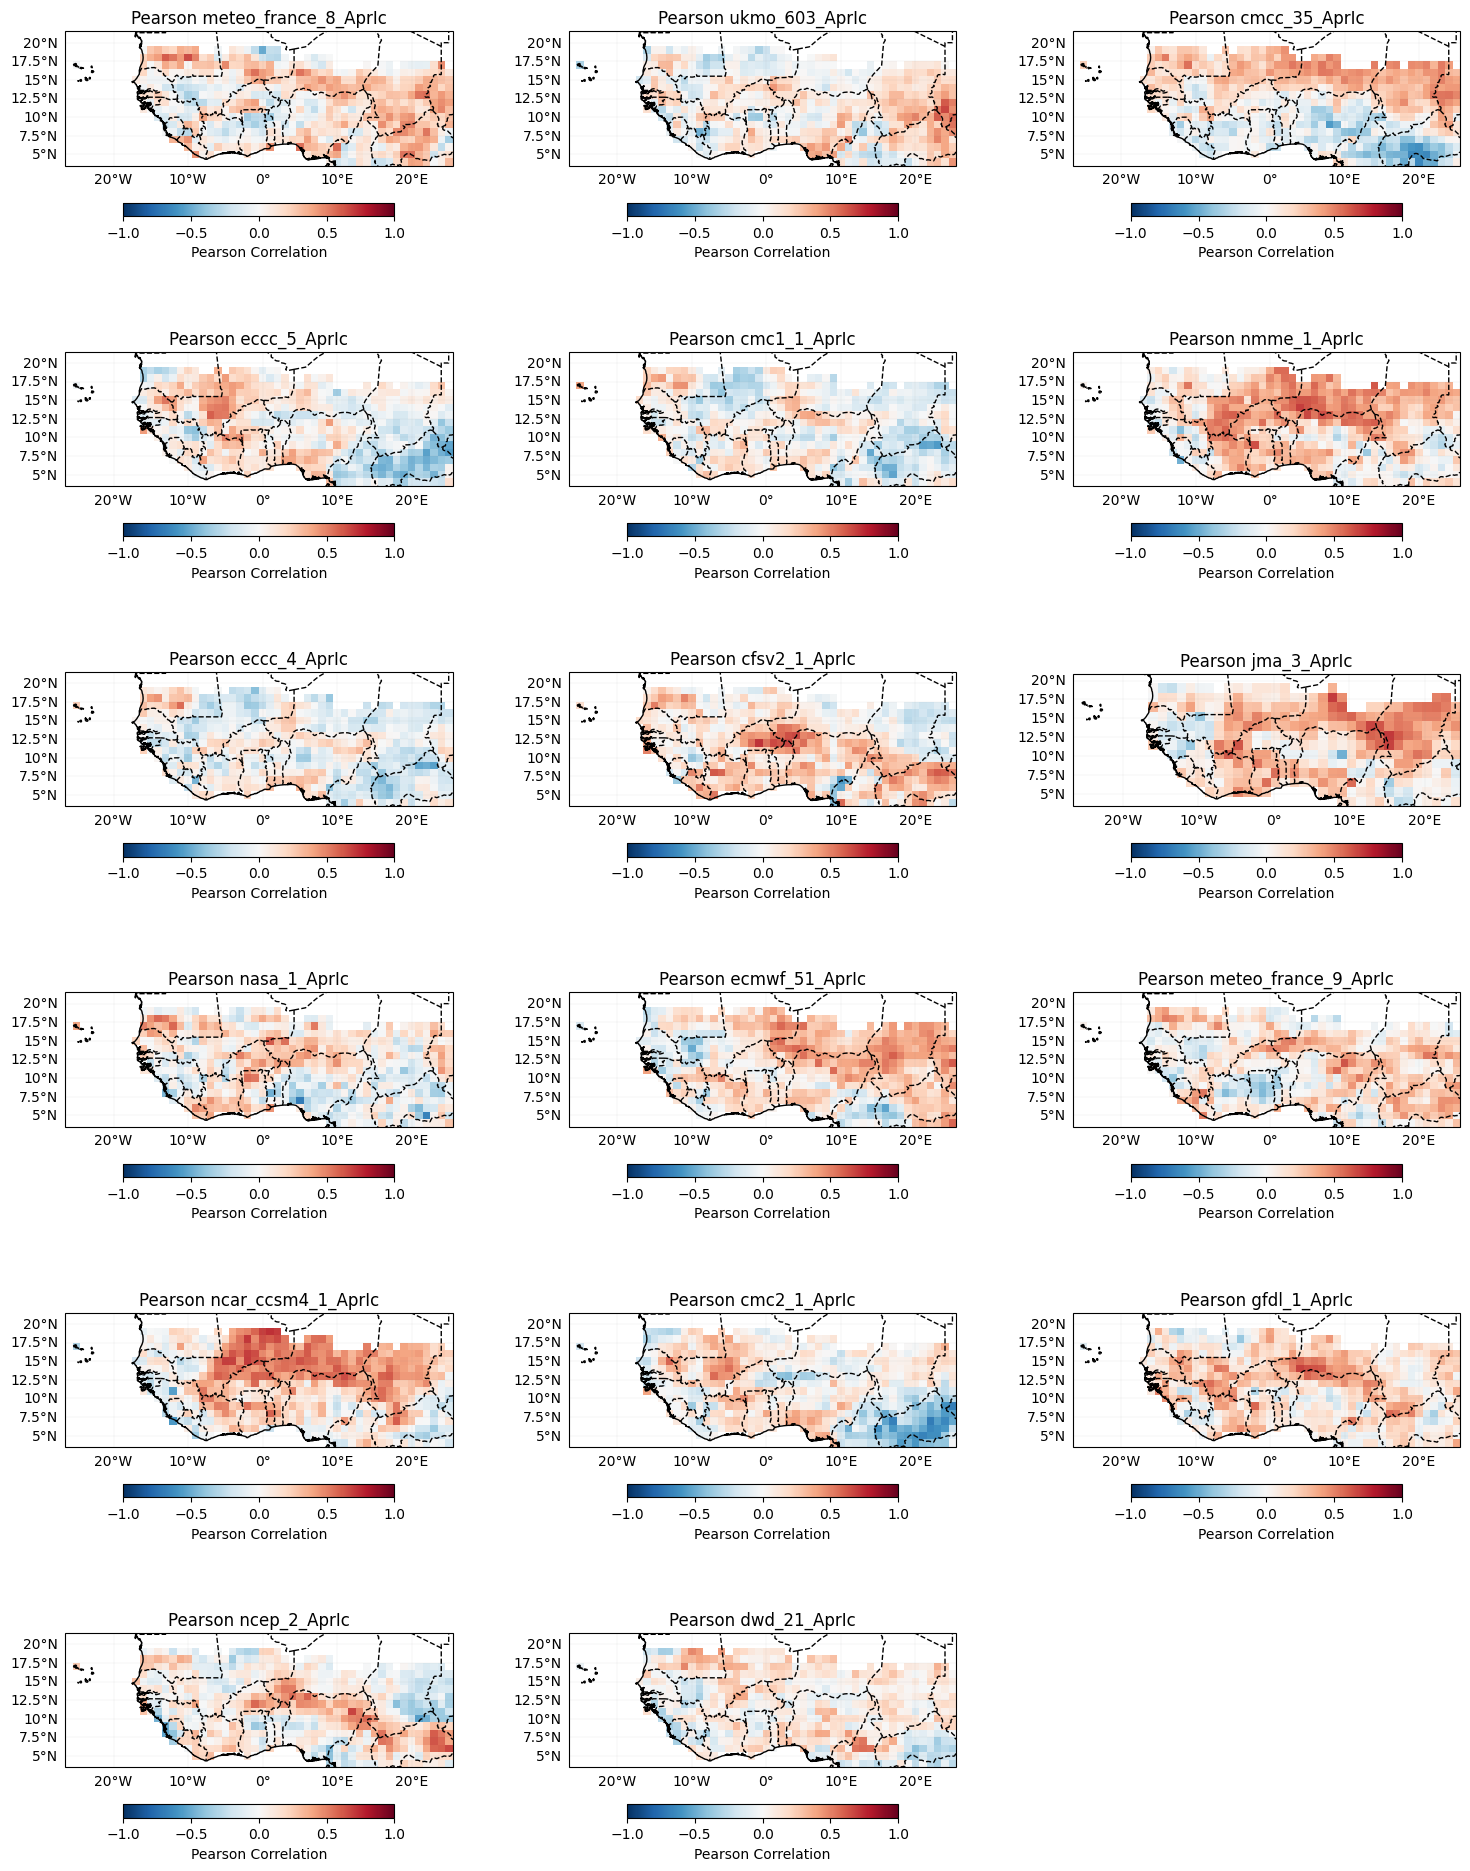

Mean Absolute Error


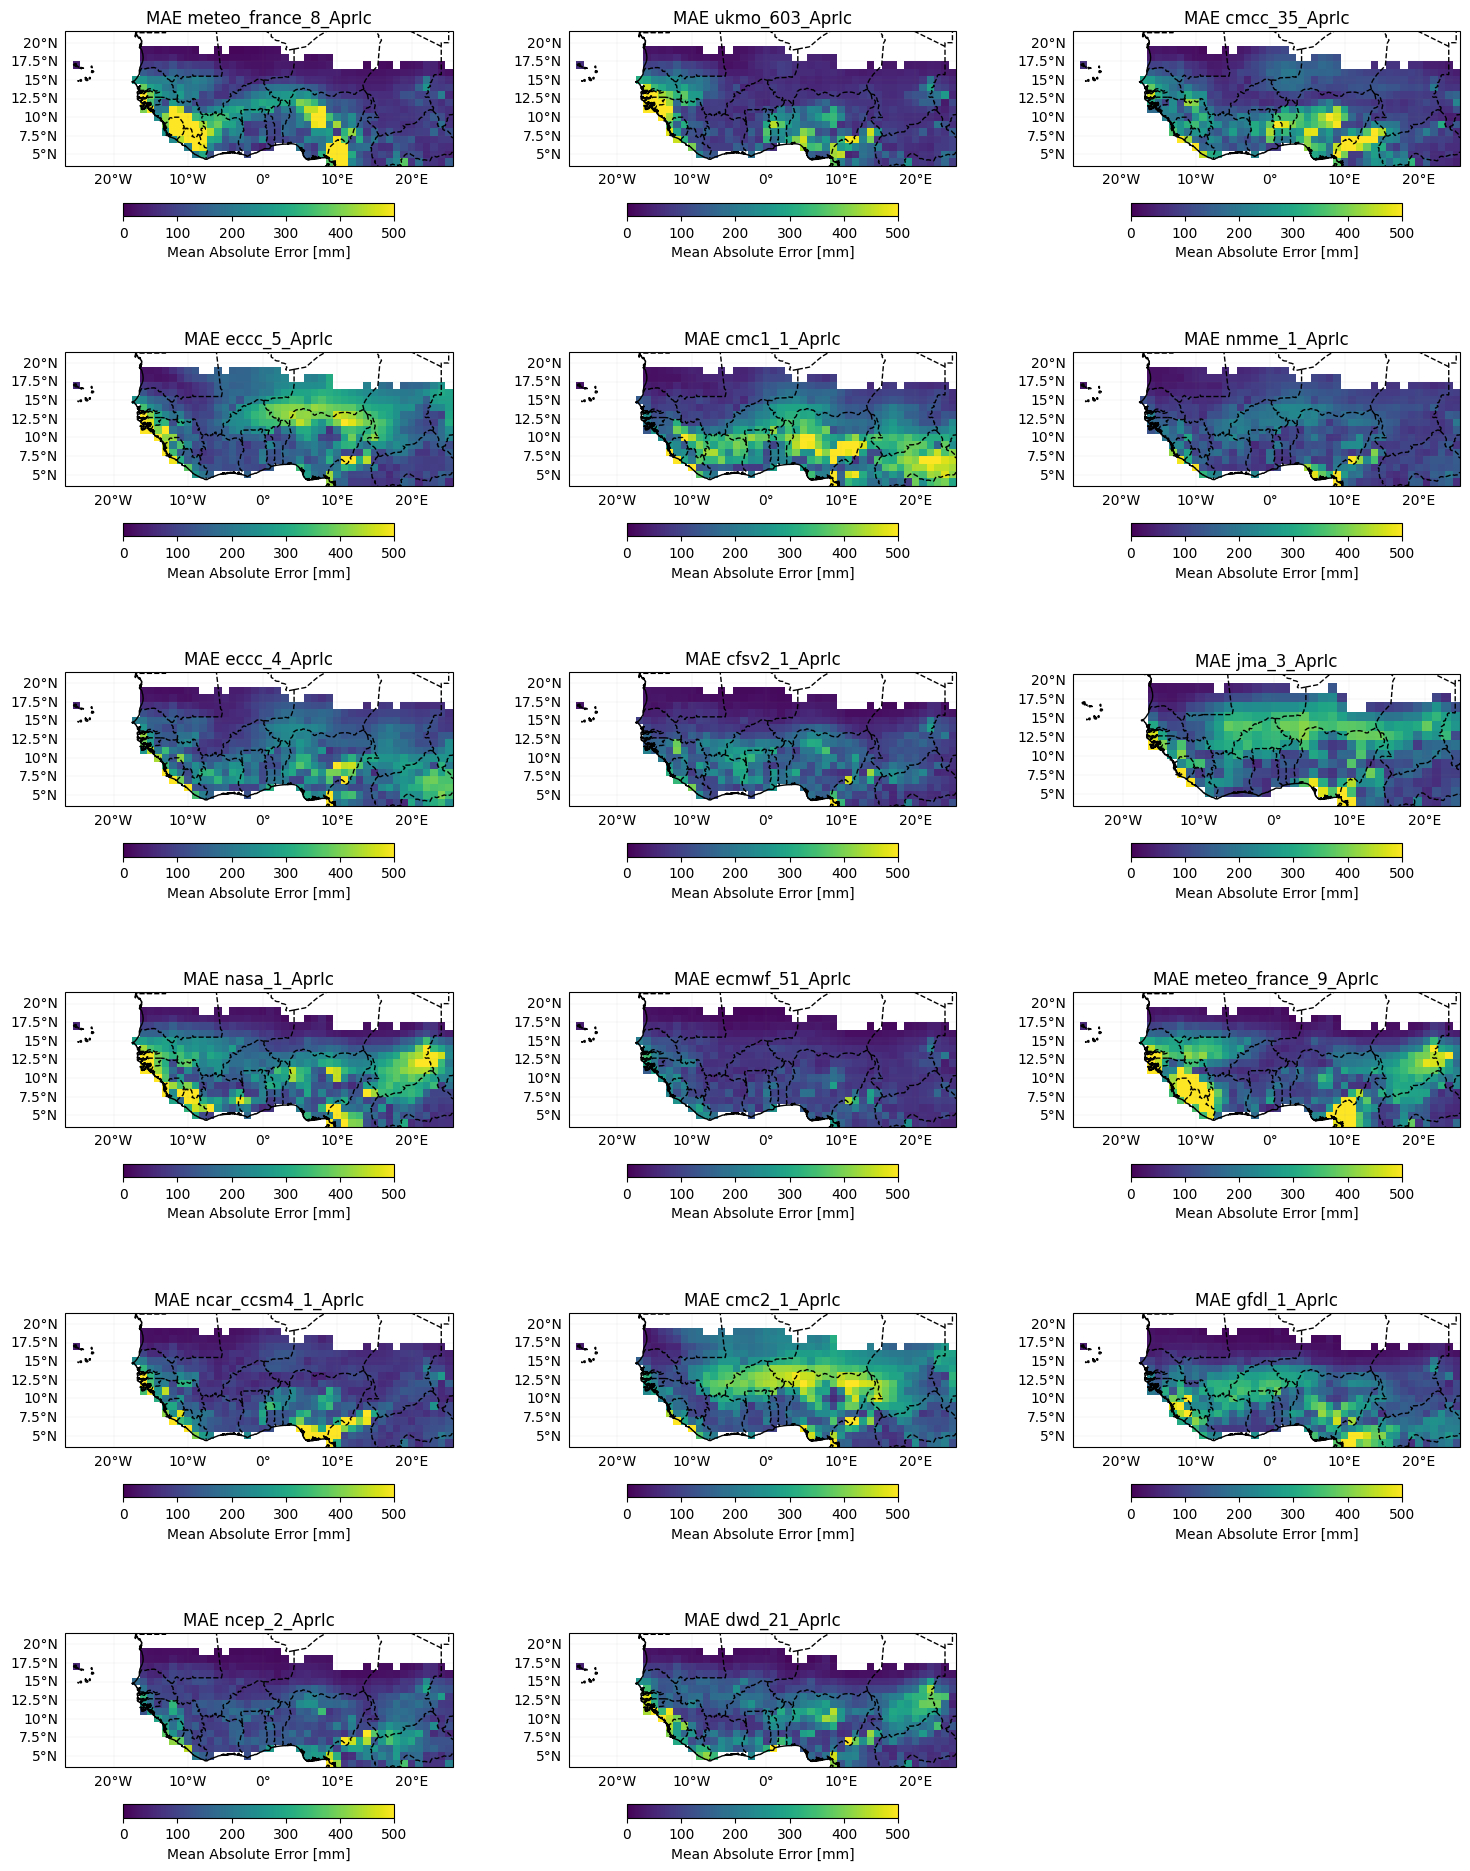

In [26]:
# score.append('GROC') if 'GROC' not in score else score
os.makedirs(dir_save_score, exist_ok=True)
scores = {}
for i in score:
    scores[i] = was_verify.gcm_validation_compute(hindcast_files, rainfall, i, month_of_initialization, clim_year_start, clim_year_end, dir_save_score, lead_time = None, ensemble_mean=None, gridded=True)
    print(was_verify.scores[i][0])
    was_verify.plot_models_score(scores[i], i, dir_save_score)
    r = scores[i]

# SV-ML-CMME

## Choice of best GCM models

In [28]:
best_models = get_best_models(center_variable, scores, metric='MAE', threshold=200, top_n=5, gcm=True)
best_models 

['ECMWF_51.PRCP',
 'NMME_1.PRCP',
 'NCEP_2.PRCP',
 'NCAR_CCSM4_1.PRCP',
 'CFSV2_1.PRCP']

In [118]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### MLP

In [30]:
# from scipy.stats import loguniform
model = WAS_mme_MLP(
    hidden_layer_sizes_range=[(2,4), (4,8), (8,16), (16,24), (24,32)], #(32,40)],
    learning_rate_init_range=loguniform(1e-4, 1e-2),
    activation_options=['relu', 'tanh','identity'],        
    solver_options=['adam'],# 'sgd', 'lbfgs'],           
    alpha_range=loguniform(1e-4, 1e-1),   
    search_method='bayesian',                              
    random_state=42,
    n_iter_search=25,  
    max_iter=2000,
    cv_folds=5,
    n_clusters=3,
    dist_method=dist_method,
    optuna_n_jobs=-1,
    optuna_timeout=600
)

#### Cross-validation

In [31]:
# all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), gcm=True, ELM_ELR=True, dir_to_save_model=dir_to_save_model, best_models=best_models, scores=scores, year_start=year_start_model, year_end=year_end_model, model=True, month_of_initialization=month_of_initialization, lead_time=lead_time, year_forecast=forecast)
all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), hdcsted=hindcast_files, fcsted=forecast_files, scores= scores, score_metric='MAE', gcm=True, agroparam=False, ELM_ELR=False, best_models=best_models, dir_to_save_model=dir_to_save_model, year_start=year_start_model, year_end=year_end_model, model=True, month_of_initialization=month_of_initialization, lead_time=lead_time, year_forecast=forecast)

In [32]:
best_params, cluster = model.compute_hyperparameters(all_model_hdcst, obs, clim_year_start, clim_year_end)

[I 2026-02-05 06:52:50,699] A new study created in memory with name: no-name-89834a19-2dd8-4e65-902a-7d2186c08f65
[I 2026-02-05 06:53:15,698] Trial 4 finished with value: -0.9734142750511783 and parameters: {'hidden_layer_sizes': (2, 4), 'activation': 'identity', 'solver': 'adam', 'learning_rate_init': 0.0018406448910921885, 'alpha': 0.010470443344014898}. Best is trial 4 with value: -0.9734142750511783.
/home/user/miniconda3/envs/WASS2S/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:697: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/home/user/miniconda3/envs/WASS2S/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:697: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/home/user/miniconda3/envs/WASS2S/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:697: UserWarning: Training interrupted by user.
  warnings.war

In [ ]:
best_params #= {'activation': 'lin', 'neurons': 200, 'norm': 37.38460883888426}

In [ ]:
cluster.plot()

In [ ]:
was_mme_gcm = WAS_Cross_Validator(n_splits=len(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))).get_index("T")), nb_omit=2)

In [ ]:
if dist_method=="bestfit":
    hindcast_det_gcm, hindcast_prob_gcm, = was_mme_gcm.cross_validate(model, obs, all_model_hdcst, clim_year_start, 
                                                                  clim_year_end, best_params=best_params, cluster_da=cluster,
                                                                  best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    hindcast_det_gcm, hindcast_prob_gcm, = was_mme_gcm.cross_validate(model, obs, all_model_hdcst, clim_year_start,
                                                                  clim_year_end, best_params=best_params, cluster_da=cluster
                                                                     )    
hdcst_consolidated['SV-ML-CMME_MLP'] = hindcast_det_gcm
hdcst_consolidated_prob['SV-ML-CMME_MLP'] = hindcast_prob_gcm

In [ ]:
was_verify = WAS_Verification(dist_method=dist_method, mae_rmse_crps_thrsd=250)

#### Verification

In [ ]:
score = ['Pearson', 'MAE']
model_name = "MLP" #"Extreme Learning Machine" # Extreme Learning Machine "MultiLayer Perceptron" XGBoost Random Forest

In [ ]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_det_gcm
    )
    scores_consolidated[i] = {'SV-ML-CMME_MLP': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

##### Probabilistic

In [ ]:
score = ['GROC', 'RPSS']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_prob_gcm,
        clim_year_start,
        clim_year_end)
    scores_consolidated[i] = {'SV-ML-CMME_MLP': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

#### Forecast 

In [ ]:
if dist_method=="bestfit":
    forecast_det_gcm, forecast_prob_gcm= model.forecast(obs, clim_year_start, clim_year_end, all_model_hdcst, hindcast_det_gcm, all_model_fcst, best_params=best_params, cluster_da=cluster, 
                                                        best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    forecast_det_gcm, forecast_prob_gcm= model.forecast(obs, clim_year_start, clim_year_end, all_model_hdcst, hindcast_det_gcm, 
                                                        all_model_fcst, best_params=best_params, cluster_da=cluster
                                                       )
    
fcst_consolidated['SV-ML-CMME_MLP'] = forecast_det_gcm
fcst_consolidated_prob['SV-ML-CMME_MLP'] = forecast_prob_gcm
plot_prob_forecasts(f"{dir_to_forecast}", forecast_prob_gcm.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast} Initial conditions of {calendar.month_name[int(month_of_initialization)]}",
                    hspace=-0.6, labels=fcst_labels, reverse_cmap=False)
gc.collect()

### Extreme Learning

In [ ]:
model = WAS_mme_hpELM(neurons_range=[5, 10, 20, 50, 100, 200, 250], #400, 600, 700, 800, 1000],   
                        activation_options=['lin', 'sigm', 'tanh'],#  'rbf_l1', 'rbf_l2', 'rbf_linf'],
                        norm_range=loguniform(0.1, 100.0),            
                        random_state=42,
                        n_iter_search=30,                             
                        cv_folds=5,
                        dist_method=dist_method,
                        search_method='bayesian',
                        n_clusters=4,
                        n_trials_bayesian=100,
                        bayesian_sampler='tpe', #random or tpe
                        )

#### Cross-validation

In [ ]:
# all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), gcm=True, ELM_ELR=True, dir_to_save_model=dir_to_save_model, best_models=best_models, scores=scores, year_start=year_start_model, year_end=year_end_model, model=True, month_of_initialization=month_of_initialization, lead_time=lead_time, year_forecast=forecast)
all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), hdcsted=hindcast_files, fcsted=forecast_files, scores= scores, score_metric='MAE', gcm=True, agroparam=False, ELM_ELR=False, best_models=best_models, dir_to_save_model=dir_to_save_model, year_start=year_start_model, year_end=year_end_model, model=True, month_of_initialization=month_of_initialization, lead_time=lead_time, year_forecast=forecast)

In [ ]:
best_params, cluster = model.compute_hyperparameters(all_model_hdcst, obs, clim_year_start, clim_year_end)

In [ ]:
best_params #= {'activation': 'lin', 'neurons': 200, 'norm': 37.38460883888426}

In [ ]:
cluster.plot()

In [ ]:
was_mme_gcm = WAS_Cross_Validator(n_splits=len(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))).get_index("T")), nb_omit=2)

In [ ]:
if dist_method=="bestfit":
    hindcast_det_gcm, hindcast_prob_gcm, = was_mme_gcm.cross_validate(model, obs, all_model_hdcst, clim_year_start, 
                                                                  clim_year_end, best_params=best_params, cluster_da=cluster,
                                                                  best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    hindcast_det_gcm, hindcast_prob_gcm, = was_mme_gcm.cross_validate(model, obs, all_model_hdcst, clim_year_start,
                                                                  clim_year_end, best_params=best_params, cluster_da=cluster
                                                                     )    
hdcst_consolidated['SV-ML-CMME_ELM'] = hindcast_det_gcm
hdcst_consolidated_prob['SV-ML-CMME_ELM'] = hindcast_prob_gcm

#### Verification

In [ ]:
score = ['Pearson', 'MAE']
model_name = "Extreme Learning Machine" #"Extreme Learning Machine" # Extreme Learning Machine "MultiLayer Perceptron" XGBoost Random Forest

In [ ]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_det_gcm
    )
    scores_consolidated[i] = {'SV-ML-CMME_ELM': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

##### Probabilistic

In [ ]:
score = ['GROC', 'RPSS']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_prob_gcm,
        clim_year_start,
        clim_year_end)
    scores_consolidated[i] = {'SV-ML-CMME_ELM': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

#### Forecast 

In [ ]:
if dist_method=="bestfit":
    forecast_det_gcm, forecast_prob_gcm= model.forecast(obs, clim_year_start, clim_year_end, all_model_hdcst, hindcast_det_gcm, all_model_fcst, best_params=best_params, cluster_da=cluster, 
                                                        best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    forecast_det_gcm, forecast_prob_gcm= model.forecast(obs, clim_year_start, clim_year_end, all_model_hdcst, hindcast_det_gcm, 
                                                        all_model_fcst, best_params=best_params, cluster_da=cluster
                                                       )
    
fcst_consolidated['SV-ML-CMME_ELM'] = forecast_det_gcm
fcst_consolidated_prob['SV-ML-CMME_ELM'] = forecast_prob_gcm
plot_prob_forecasts(f"{dir_to_forecast}", forecast_prob_gcm.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast} Initial conditions of {calendar.month_name[int(month_of_initialization)]}",
                    hspace=-0.6, labels=fcst_labels, reverse_cmap=False)
gc.collect()

[W 2026-02-05 06:54:16,550] Trial 7 failed with parameters: {'hidden_layer_sizes': (4, 8), 'activation': 'tanh', 'solver': 'adam', 'learning_rate_init': 0.005945379071588446, 'alpha': 0.018250112671712258} because of the following error: BrokenProcessPool('A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.').
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/home/user/miniconda3/envs/WASS2S/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py", line 453, in _process_worker
    call_item = call_queue.get(block=True, timeout=timeout)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/user/miniconda3/envs/WASS2S/lib/python3.12/multiprocessing/queues.py", line 108, in get
    if not self._rlock.acquire(block, timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
"""

The above exception was the direct cause of the followin

In [34]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2nd - Approach: CCA-Based Calibration

In [35]:
# Filter model names to identify precipitation-related models
center_variable = [key for key in downloader.ModelsName().keys() if "SST" in key]
# center_variable.remove('NASA_1.SST')
# center_variable.remove('UKMO_603.SST')
# center_variable.remove('DWD_21.SST')
center_variable.remove('CMC2_1.SST')
# center_variable.remove('METEOFRANCE_8.SST')

# Specify the directory to save downloaded model data
dir_to_save_model = f"{dir_s2s}/model_data"

# Define the month for model initialization (June)
month_of_initialization = "04"

# Define lead times corresponding to seasonal forecast targets (JAS season in this case)
lead_time = ["03", "04", "05"]  # July-August-September forecast period

# Define the hindcast period for model data (years 1993 to 2016)
year_start_model = 1993
year_end_model = 2016

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent = [60, -180, -60, 180]  # [Northern, Western, Southern and Eastern] 

# Define if you want to download forecast or hindcast
forecast = None

# Define if you want all members of ensemble or doing an ensemble mean
ensemble_mean = "mean"

# Specify whether to overwrite existing files when downloading data
force_download = False

In [36]:
hindcast_files = downloader.WAS_Download_Models(
    dir_to_save_model,
    center_variable,
    month_of_initialization,
    lead_time,
    year_start_model,
    year_end_model,
    extent, 
    forecast,
    ensemble_mean,
    force_download)

PRCP_JAS_2024_ic_4/model_data/hindcast_bom2_SST_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/hindcast_ecmwf51_SST_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/hindcast_ukmo604_SST_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/hindcast_ukmo603_SST_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/hindcast_meteofrance8_SST_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/hindcast_meteofrance9_SST_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/hindcast_dwd21_SST_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/hindcast_dwd22_SST_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/hindcast_cmcc35_SST_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_d

In [15]:
forecast = 2024

In [16]:
forecast_files = downloader.WAS_Download_Models(
    dir_to_save_model,
    center_variable,
    month_of_initialization,
    lead_time,
    year_start_model,
    year_end_model,
    extent, 
    forecast,
    ensemble_mean,
    force_download)

2026-02-06 05:25:49,420 INFO Request ID is fc30d490-c1f5-4f6f-b366-17694f7b3b11
2026-02-06 05:25:49,628 INFO status has been updated to accepted
2026-02-06 05:26:12,012 INFO status has been updated to failed


Failed to download data for SST: 400 Client Error: Bad Request for url: https://cds.climate.copernicus.eu/api/retrieve/v1/jobs/fc30d490-c1f5-4f6f-b366-17694f7b3b11/results
The job has failed
MARS returned no data, please check your selection.Request submitted to the MARS server:
[{'area': ['60', '-180', '-60', '180'], 'fcmonth': ['03', '04', '05'], 'origin': ['ammc'], 'type': ['fcmean'], 'system': ['2'], 'param': ['34'], 'time': ['all'], 'class': ['c3'], 'expect': ['any'], 'expver': ['1'], 'method': ['1'], 'number': ['all'], 'stream': ['msmm'], 'levtype': ['sfc'], 'database': 'ecmwf', 'date': ['2024-04-01']}]

The job failed with: MarsNoDataError
PRCP_JAS_2024_ic_4/model_data/forecast_ecmwf51_SST_AprIc_JulAugSep_03.nc already exists. Skipping download.


2026-02-06 05:26:14,172 INFO Request ID is 8e558a47-1f96-4d71-83e1-3d2576e7c041
2026-02-06 05:26:14,502 INFO status has been updated to accepted
2026-02-06 05:26:23,461 INFO status has been updated to running
2026-02-06 05:26:37,171 INFO status has been updated to failed


Failed to download data for SST: 400 Client Error: Bad Request for url: https://cds.climate.copernicus.eu/api/retrieve/v1/jobs/8e558a47-1f96-4d71-83e1-3d2576e7c041/results
The job has failed
MARS returned no data, please check your selection.Request submitted to the MARS server:
[{'area': ['60', '-180', '-60', '180'], 'fcmonth': ['03', '04', '05'], 'origin': ['egrr'], 'type': ['fcmean'], 'system': ['604'], 'param': ['34'], 'time': ['all'], 'class': ['c3'], 'expect': ['any'], 'expver': ['1'], 'method': ['1'], 'number': ['all'], 'stream': ['msmm'], 'levtype': ['sfc'], 'database': 'ecmwf', 'date': ['2024-04-01']}]

The job failed with: MarsNoDataError
PRCP_JAS_2024_ic_4/model_data/forecast_ukmo603_SST_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/forecast_meteofrance8_SST_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/forecast_meteofrance9_SST_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_

2026-02-06 05:26:38,997 INFO Request ID is c267e029-d172-4cc6-a6fa-97e84d26125d
2026-02-06 05:26:41,699 INFO status has been updated to accepted
2026-02-06 05:26:56,520 INFO status has been updated to failed


Failed to download data for SST: 400 Client Error: Bad Request for url: https://cds.climate.copernicus.eu/api/retrieve/v1/jobs/c267e029-d172-4cc6-a6fa-97e84d26125d/results
The job has failed
MARS returned no data, please check your selection.Request submitted to the MARS server:
[{'area': ['60', '-180', '-60', '180'], 'fcmonth': ['03', '04', '05'], 'origin': ['edzw'], 'type': ['fcmean'], 'system': ['22'], 'param': ['34'], 'time': ['all'], 'class': ['c3'], 'expect': ['any'], 'expver': ['1'], 'method': ['1'], 'number': ['all'], 'stream': ['msmm'], 'levtype': ['sfc'], 'database': 'ecmwf', 'date': ['2024-04-01']}]

The job failed with: MarsNoDataError
PRCP_JAS_2024_ic_4/model_data/forecast_cmcc35_SST_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/forecast_ncep2_SST_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_data/forecast_jma3_SST_AprIc_JulAugSep_03.nc already exists. Skipping download.
PRCP_JAS_2024_ic_4/model_d

In [37]:
hindcast_files = {k: hindcast_files[k] for k in hindcast_files.keys() & forecast_files.keys()}
forecast_files = {k: forecast_files[k] for k in hindcast_files.keys() & forecast_files.keys()}
common_keys = {k.lower() for k in hindcast_files} & {k.lower() for k in forecast_files}
center_variable = [
    item
    for item in center_variable
    if any(item.lower().startswith(k) for k in list(common_keys))
                ]

In [38]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
center_variable = ["ECMWF_51.SST"]

### Initialize the WAS_CCA class (default)

In [40]:
n_modes = 5
# define zone as dict : {'zone_name_key': ('Explicit_Zone_name', lon_min, lon_max, lat_min, lat_max)} 
defined_zone = {'A': ('A', -150, 150, -45, 45)}  

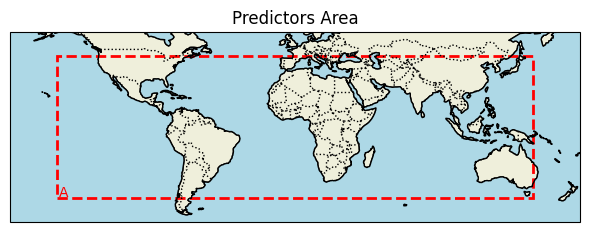

In [41]:
plot_map([extent[1],extent[3],extent[2],extent[0]], sst_indices = defined_zone, title="Predictors Area",fig_size=(6,4))

##### Modes of CCA for each model

In [42]:
was_cca = WAS_CCA(n_modes=n_modes, n_pca_modes=10, dist_method=dist_method)
was_cv = WAS_Cross_Validator(n_splits=len(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))).get_index("T")), nb_omit=2)

CCA Modes for model ECMWF_51.SST


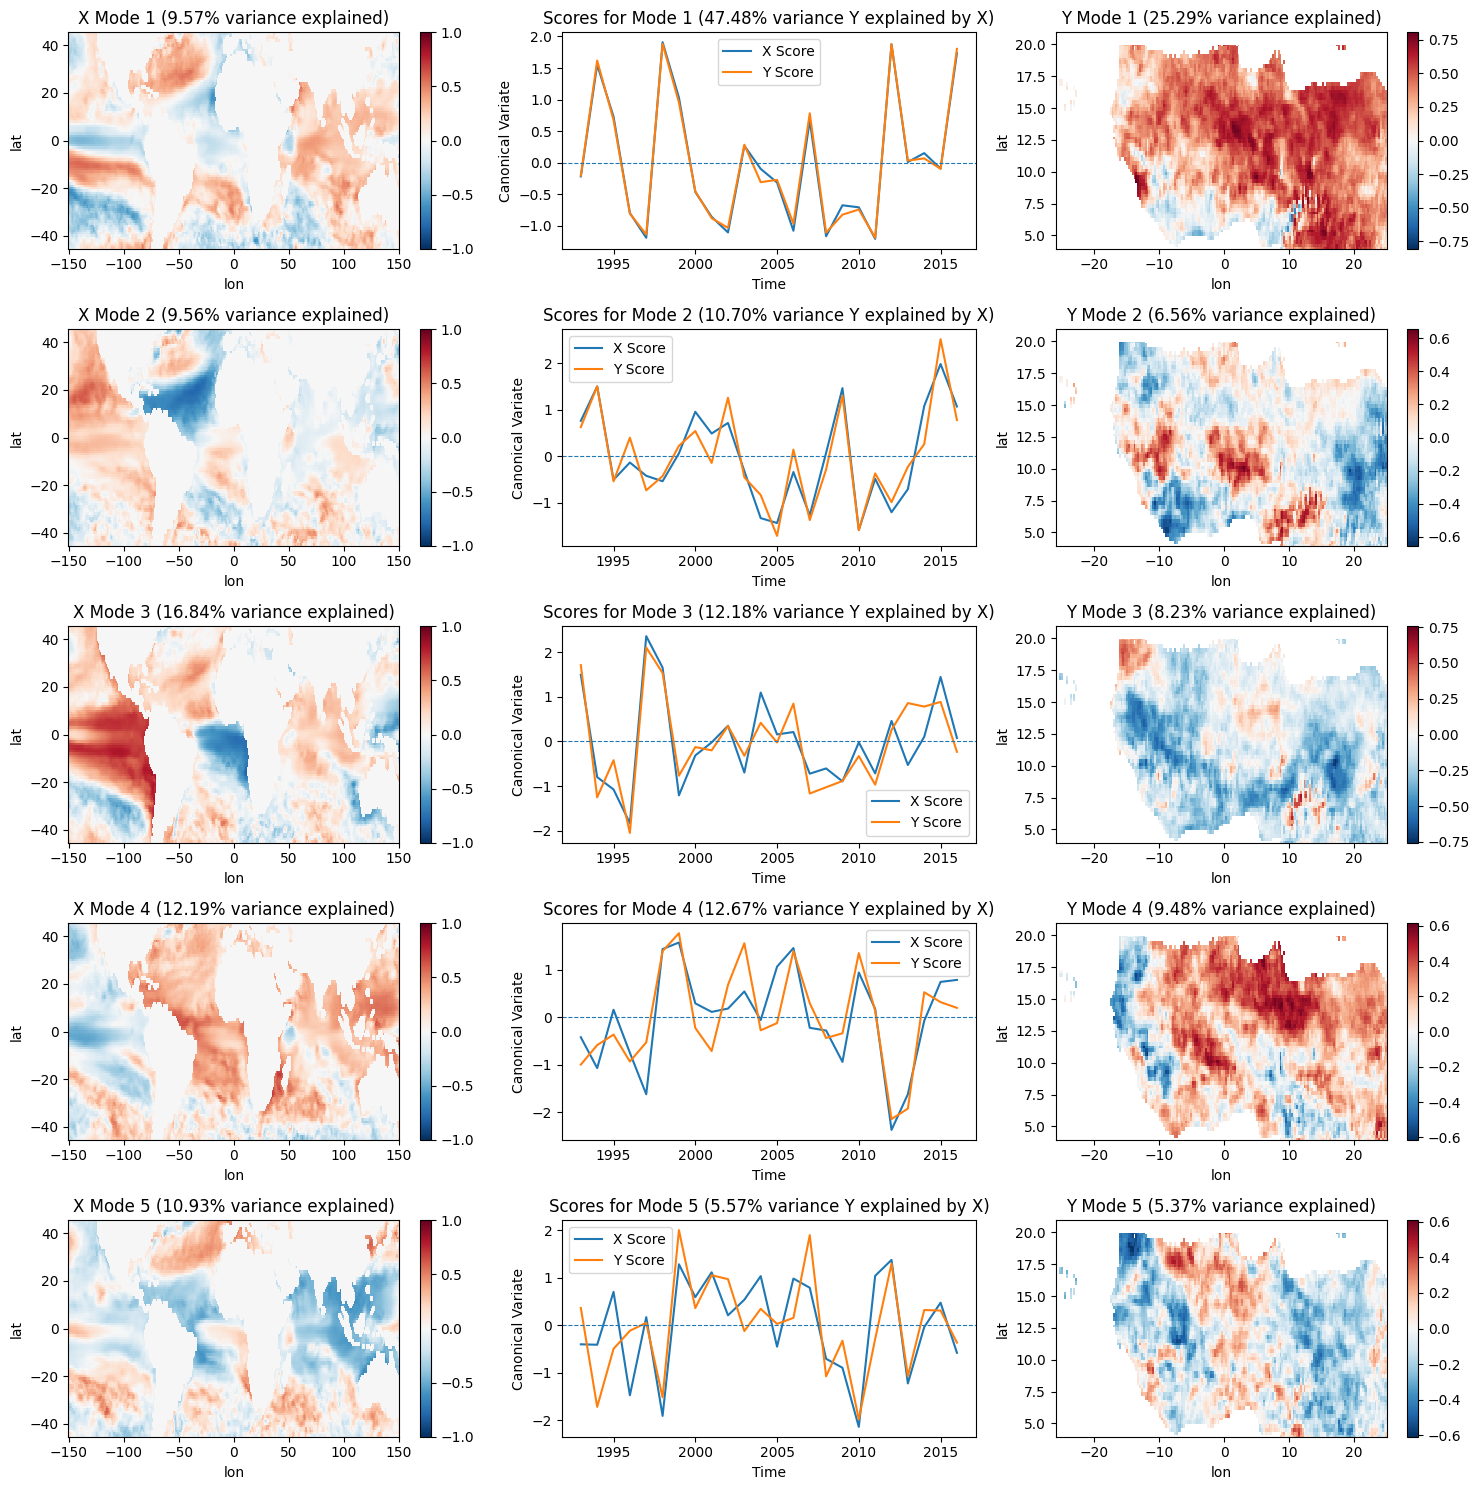

In [43]:
predictors = {}
for i in center_variable:
    predictors[i] = retrieve_single_zone_for_PCR(dir_to_save_model, defined_zone, i, year_start_model, year_end_model, clim_year_start=clim_year_start, clim_year_end=clim_year_end, model=True, month_of_initialization=month_of_initialization, lead_time=lead_time)
    predictor = predictors[i].isel(T = slice(None,-1))
    predictor['T'] = rainfall.sel(T=slice(str(year_start_model),str(year_end_model)))['T']
    print(f"CCA Modes for model {i}")
    was_cca.plot_cca_results(X=predictor, Y=rainfall.sel(T=slice(str(year_start_model),str(year_end_model))) , clim_year_start=clim_year_start, clim_year_end=clim_year_end)

#### Cross validation

In [44]:
hindcast_det_dynam_all = {}
hindcast_prob_dynam_all = {}
for key, predictor in predictors.items():
    predictor = predictor.isel(T = slice(None,-1))
    predictor['T'] = rainfall.sel(T=slice(str(year_start_model),str(year_end_model)))['T']
    print(key.split(".")[0])
    if dist_method=="bestfit":
        hindcast_det_dynam_all[key], hindcast_prob_dynam_all[key] = was_cv.cross_validate(was_cca, rainfall.sel(T=slice(str(year_start_model),str(year_end_model))).sel(T=slice(str(year_start_model),str(year_end_model))), 
                                                                                          predictor, clim_year_start, clim_year_end, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
    else:
        hindcast_det_dynam_all[key], hindcast_prob_dynam_all[key] = was_cv.cross_validate(was_cca, rainfall.sel(T=slice(str(year_start_model),str(year_end_model))).sel(T=slice(str(year_start_model),str(year_end_model))), predictor, clim_year_start, clim_year_end) 

ECMWF_51
Cross-validation ongoing


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [00:25<00:00,  1.06s/it]


[4.39064911e-06 6.04935086e-06 6.04935086e-06 ... 9.99951902e-01
 9.99951902e-01            nan]


#### Verification (individual)

###### Deterministic

In [25]:
score = ['Pearson','MAE']
model_name = "CCA-based"

Pearson Correlation


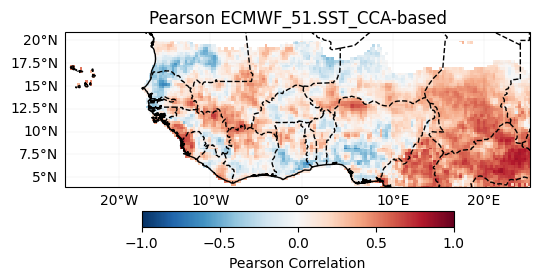

Mean Absolute Error


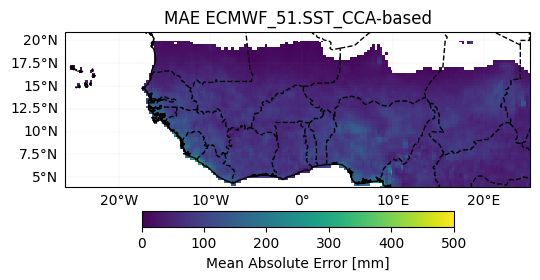

In [26]:
cca_scores = {}
for i in score:
    tmp = {}
    print(was_verify.scores[i][0])
    for key, hdcst in hindcast_det_dynam_all.items():
        tmp[f'{key}_snd.approach'] = was_verify.compute_deterministic_score(
            was_verify.get_scores_metadata()[i][5],
            rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
            hindcast_det_dynam_all[key]
        )
        was_verify.plot_model_score(tmp[f'{key}_snd.approach'], i, dir_save_score, f"{key}_{model_name}")
    cca_scores[i] = tmp

###### Probabilistic

In [45]:
score = ['GROC', 'RPSS']

In [46]:
hindcast_prob_dynam_all["ECMWF_51.SST"]

<xarray.DataArray (probability: 3, T: 24, Y: 170, X: 510)> Size: 50MB
array([[[[       nan,        nan,        nan, ..., 0.04863719,
          0.14603865, 0.14603865],
         [       nan,        nan,        nan, ..., 0.10684695,
          0.03603612, 0.03603612],
         [       nan,        nan,        nan, ..., 0.10684695,
          0.03603612, 0.03603612],
         ...,
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan]],

        [[       nan,        nan,        nan, ..., 0.07675502,
          0.18826109, 0.18826109],
         [       nan,        nan,        nan, ..., 0.20711872,
          0.05546074, 0.05546074],
         [       nan,        nan,        nan, ..., 0.20711872,
          0.05546074, 0.05546074],
...
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan]],

        [[       nan,        nan,        nan, ..., 0.20543395,
          0.39486581, 0.39486581],
         [       nan,        nan,        nan, ..., 0.28028755,
          0.1108627 , 0.1108627 ],
         [       nan,        nan,        nan, ..., 0.28028755,
          0.1108627 , 0.1108627 ],
         ...,
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan]]]])
Coordinates:
  * Y            (Y) float64 1kB 4.0 4.1 4.2 4.3 4.4 ... 20.6 20.7 20.8 20.9
  * X            (X) float64 4kB -25.9 -25.8 -25.7 -25.6 ... 24.7 24.8 24.9 25.0
  * T            (T) datetime64[ns] 192B 1993-08-01 1994-08-01 ... 2016-08-01
  * probability  (probability) <U2 24B 'PB' 'PN' 'PA'
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-26T19:29 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    tmp = {}
    print(was_verify.scores[i][0])
    for key, hdcst in hindcast_det_dynam_all.items():
        tmp[f'{key}_snd.approach'] = was_verify.compute_probabilistic_score(
            was_verify.get_scores_metadata()[i][5],
            rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
            hindcast_prob_dynam_all[key],
            clim_year_start,
            clim_year_end)
        was_verify.plot_model_score(tmp[f'{key}_snd.approach'], i, dir_save_score, f"{key}_{model_name}")
    cca_scores[i] = tmp

#### Forecast (individual)

In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ECMWF_51


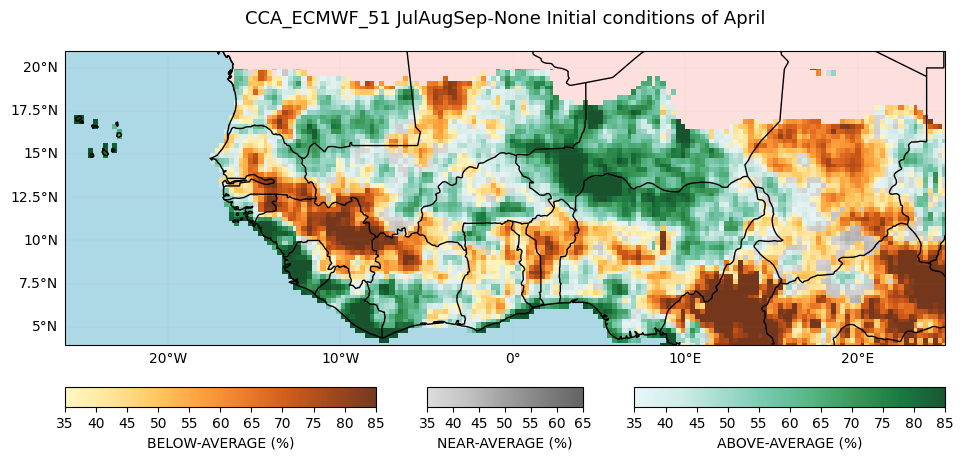

In [47]:
forecast_det_dynam_all = {}
forecast_prob_dynam_all = {}
for key, predictor in predictors.items():
    predictor_f = predictor.isel(T=[-1])
    predictor = predictor.isel(T = slice(None,-1))
    predictor['T'] = rainfall.sel(T=slice(str(year_start_model),str(year_end_model)))['T']
    print(key.split(".")[0])
    if dist_method=="bestfit":
        forecast_det_dynam_all[key], forecast_prob_dynam_all[key] = was_cca.forecast(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, predictor, hindcast_det_dynam_all[key], predictor_f, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
    else:
        forecast_det_dynam_all[key], forecast_prob_dynam_all[key] = was_cca.forecast(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, predictor, hindcast_det_dynam_all[key], predictor_f)
    model_name = f"CCA_{key.split(".")[0]}"    
    plot_prob_forecasts(f"{dir_to_forecast}",
                        forecast_prob_dynam_all[key].drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast} Initial conditions of {calendar.month_name[int(month_of_initialization)]}", 
                        hspace=-0.6, labels=fcst_labels, reverse_cmap=False)

### Select best Statistico-Dynamical models

In [ ]:
#### Select some models
best_models = get_best_models(center_variable, cca_scores, metric='GROC', threshold=0.6, top_n=6, gcm=False)
best_models

In [ ]:
for key in best_models:
    hdcst_consolidated[f'{key}_snd.approach'] = hindcast_det_dynam_all[key]
    fcst_consolidated[f'{key}_snd.approach'] = forecast_det_dynam_all[key]
    hdcst_consolidated_prob[f'{key}_snd.approach'] = hindcast_prob_dynam_all[key]
    fcst_consolidated_prob[f'{key}_snd.approach'] = forecast_prob_dynam_all[key]
    
for metric, models in cca_scores.items():
    for model in list(models):                    # list() pour éviter RuntimeError
        if not any(model.startswith(p) for p in best_models):
            del models[model]

for key in cca_scores:
    scores_consolidated.setdefault(key, {}).update(cca_scores[key])

In [ ]:
# score_sv_cmme[model_name] = cca_scores

# 3rd - Approach: Observation-Based with Lag (Obs-Lag) 

In [48]:
# Filter model names to identify precipitation-related models
variables_reanalysis = ["NOAA.SST"] #[key for key in downloader.ReanalysisName().keys() if "SST" in key]# or "VGRD_850" in key]

# Specify the directory to save downloaded model data
dir_to_save_Reanalysis = f"{dir_s2s}/reanalysis_data/"

# choose sequence corresponding to seasonal forecast targets (JAS season in this case)
season = ["08","09","10"]  # Jan-Feb-Mar forecast period

# Define the observation period (years 1993 to 2016)
year_start = 1991
year_end = 2024

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent = [60, -180, -60, 180]  # [Northern, Western, Southern and Eastern] 

# Specify whether to overwrite existing files when downloading data
force_download = False

In [49]:
downloader.WAS_Download_Reanalysis(
    dir_to_save_Reanalysis,
    variables_reanalysis,
    year_start,
    year_end,
    extent,
    season, 
    force_download
)

PRCP_JAS_2024_ic_4/reanalysis_data/NOAA_SST_1991_2024_AugSepOct.nc exists. Skipping.


## MLR with SST Index

##### Process SST index 

In [50]:
# Print available SST index
print(list(sst_indices_name.keys()))

['NINO34', 'NINO12', 'NINO3', 'NINO4', 'NINO_Global', 'TNA', 'TSA', 'NAT', 'SAT', 'TASI', 'WTIO', 'SETIO', 'DMI', 'MB']


In [51]:
## Choose yours
sst_index_name = ['NINO34', 'TNA', 'TSA', 'MB'] # 

# Set your own indices zones ( zones not available in built-in)
my_own_indices_zone = {
                         #'A': ('A', -55, 10, -20, 25),
                         # 'B': ('B', -170, -80, -10, 10),
                         # 'C': ('C', -10, 10, 1, 5),
                        }
others_zone = my_own_indices_zone

In [52]:
# Combine all zones
sst_indices_all = {i: sst_indices_name[i] for i in sst_index_name} 
sst_indices_all.update(my_own_indices_zone) if my_own_indices_zone is not None else {i: sst_indices_name[i] for i in sst_index_name} 

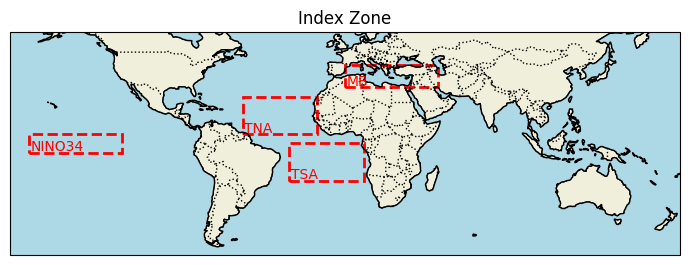

In [53]:
plot_map([extent[1],extent[3],extent[2],extent[0]], sst_indices = sst_indices_all, title="Index Zone",fig_size=(7,4))

In [54]:
predictors = compute_sst_indices(dir_to_save_Reanalysis, sst_index_name, variables_reanalysis[0], year_start, year_end, season, clim_year_start, clim_year_end, my_own_indices_zone)

NOAA SST


##### Calculate variance inflation factor to see multicolinearity predictor

In [83]:
# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["feature"] = predictors.to_dataframe().columns
vif_data["VIF"] = [VIF(predictors.to_dataframe(), i) for i in range(predictors.to_dataframe().shape[1])]
# Print VIF values
print(vif_data)

  feature       VIF
0  NINO34  1.068134
1     TNA  1.917042
2     TSA  1.684484
3      MB  2.138620


In [84]:
# Set a threshold for VIF (e.g., 10)
vif_threshold = 5

In [85]:
low_vif_predictors = vif_data[vif_data["VIF"] < vif_threshold]["feature"].tolist()
# Filter the predictors to exclude those with high VIF
filtered_predictors = predictors[low_vif_predictors].to_array()
filtered_predictors = filtered_predictors.rename({"variable": "features"}).transpose('T', 'features')
print(low_vif_predictors)

['NINO34', 'TNA', 'TSA', 'MB']


In [86]:
# Available core over machine
cpu_count()

8

In [87]:
#### Set core number for computation
nb_cores = 6

In [88]:
# Load class for model, cross-validation and verification
model = WAS_LinearRegression_Model(nb_cores = nb_cores, dist_method=dist_method)

#### Cross validation

In [89]:
# Instantiate cross-validation
was_cv = WAS_Cross_Validator(n_splits=len(rainfall.get_index("T")), nb_omit=2)

In [90]:
filtered_predictors_ = filtered_predictors.isel(T = slice(None,-1))
filtered_predictors_['T'] = rainfall['T']
if dist_method=="bestfit":
    hindcast_det_obs_seas_mlr, hindcast_prob_obs_seas_mlr = was_cv.cross_validate(model, rainfall, filtered_predictors_, clim_year_start, clim_year_end, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    hindcast_det_obs_seas_mlr, hindcast_prob_obs_seas_mlr = was_cv.cross_validate(model, rainfall, filtered_predictors_, clim_year_start, clim_year_end)
hdcst_consolidated['MLR_VIF.ERSST'] = hindcast_det_obs_seas_mlr.sel(T=slice(str(year_start_model),str(year_end_model)))
hdcst_consolidated_prob['MLR_VIF.ERSST'] = hindcast_prob_obs_seas_mlr.sel(T=slice(str(year_start_model),str(year_end_model)))

Cross-validation ongoing


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33/33 [11:02<00:00, 20.08s/it]


#### Verification

In [ ]:
score = ['Pearson','MAE']
model_name = "Observation-Based with Lag"

###### Deterministic

In [ ]:
third_scores = {}
hindcast_det_obsBased_all = {}
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall,
        hindcast_det_obs_seas_mlr
    )
    was_verify.plot_model_score(r, i, dir_save_score, model_name)
    scores_consolidated[i] = {'MLR_VIF.ERSST': r}
    third_scores[i] = {'MLR_VIF.SST': r}
hindcast_det_obsBased_all['MLR_VIF.ERSST'] = hindcast_det_obs_seas_mlr

###### Probabilistic

In [ ]:
score = ['GROC', 'RPSS']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
hindcast_prob_obsBased_all = {}
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall,
        hindcast_prob_obs_seas_mlr,
        clim_year_start,
        clim_year_end)
    was_verify.plot_model_score(r, i, dir_save_score, model_name)
    third_scores[i] = {'MLR_VIF.SST': r}
    scores_consolidated[i] = {'MLR_VIF.ERSST': r}
    # scores_consolidated[i]['MLR_VIF.ERSST'] = r
hindcast_prob_obsBased_all['MLR_VIF.ERSST'] = hindcast_prob_obs_seas_mlr

#### Forecast

In [ ]:
forecast_det_obsBased_all = {}
forecast_prob_obsBased_all = {}
f_predictors = filtered_predictors.isel(T=[-1])
f_predictors['T'] = forecast_det_gcm['T']
if dist_method=="bestfit":
    forecast_det_mlr, forecast_prob_mlr = model.forecast(rainfall, clim_year_start, clim_year_end, filtered_predictors_, hindcast_det_obs_seas_mlr, f_predictors, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    forecast_det_mlr, forecast_prob_mlr = model.forecast(rainfall, clim_year_start, clim_year_end, filtered_predictors_, hindcast_det_obs_seas_mlr, f_predictors)
    
forecast_det_obsBased_all['MLR_VIF.ERSST'] = forecast_det_mlr
forecast_prob_obsBased_all['MLR_VIF.ERSST'] = forecast_prob_mlr
fcst_consolidated['MLR_VIF.ERSST'] = forecast_det_mlr
fcst_consolidated_prob['MLR_VIF.ERSST'] = forecast_prob_mlr
plot_prob_forecasts(f"{dir_to_forecast}/{model_name}{season_str}_{forecast}_Ic_{calendar.month_name[int(month_of_initialization)]}.png", 
                    forecast_prob_mlr.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast} Initial conditions of {calendar.month_name[int(month_of_initialization)]}", 
                    hspace=-0.6, labels=fcst_labels, reverse_cmap=False)

## CCA

In [61]:
n_modes = 5
# Set your own zones ( zones not available in built-in)
# define zone as dict : {'zone_name_key': ('Explicit_Zone_name', lon_min, lon_max, lat_min, lat_max)} 
zones_for_PCR = {'A': ('A', -150, 150, -45, 45)}

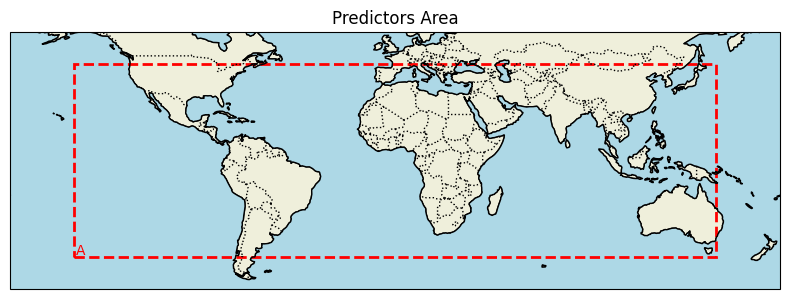

In [62]:
plot_map([extent[1],extent[3],extent[2],extent[0]], sst_indices = zones_for_PCR, title="Predictors Area",fig_size=(8,6))

In [63]:
predictor = retrieve_single_zone_for_PCR(dir_to_save_Reanalysis, zones_for_PCR, variables_reanalysis[0], year_start, year_end, season, 1991, 2020, standardize=False)

In [64]:
predictor = retrieve_single_zone_for_PCR(dir_to_save_Reanalysis, zones_for_PCR, variables_reanalysis[0], year_start, year_end, season, clim_year_start, clim_year_end)
predictor_f = predictor.isel(T=slice(None,-1))

In [65]:
was_cca_ = WAS_CCA(n_modes=n_modes, n_pca_modes=10, dist_method=dist_method)
was_cv = was_cv = WAS_Cross_Validator(n_splits=len(rainfall.get_index("T")), nb_omit=2)

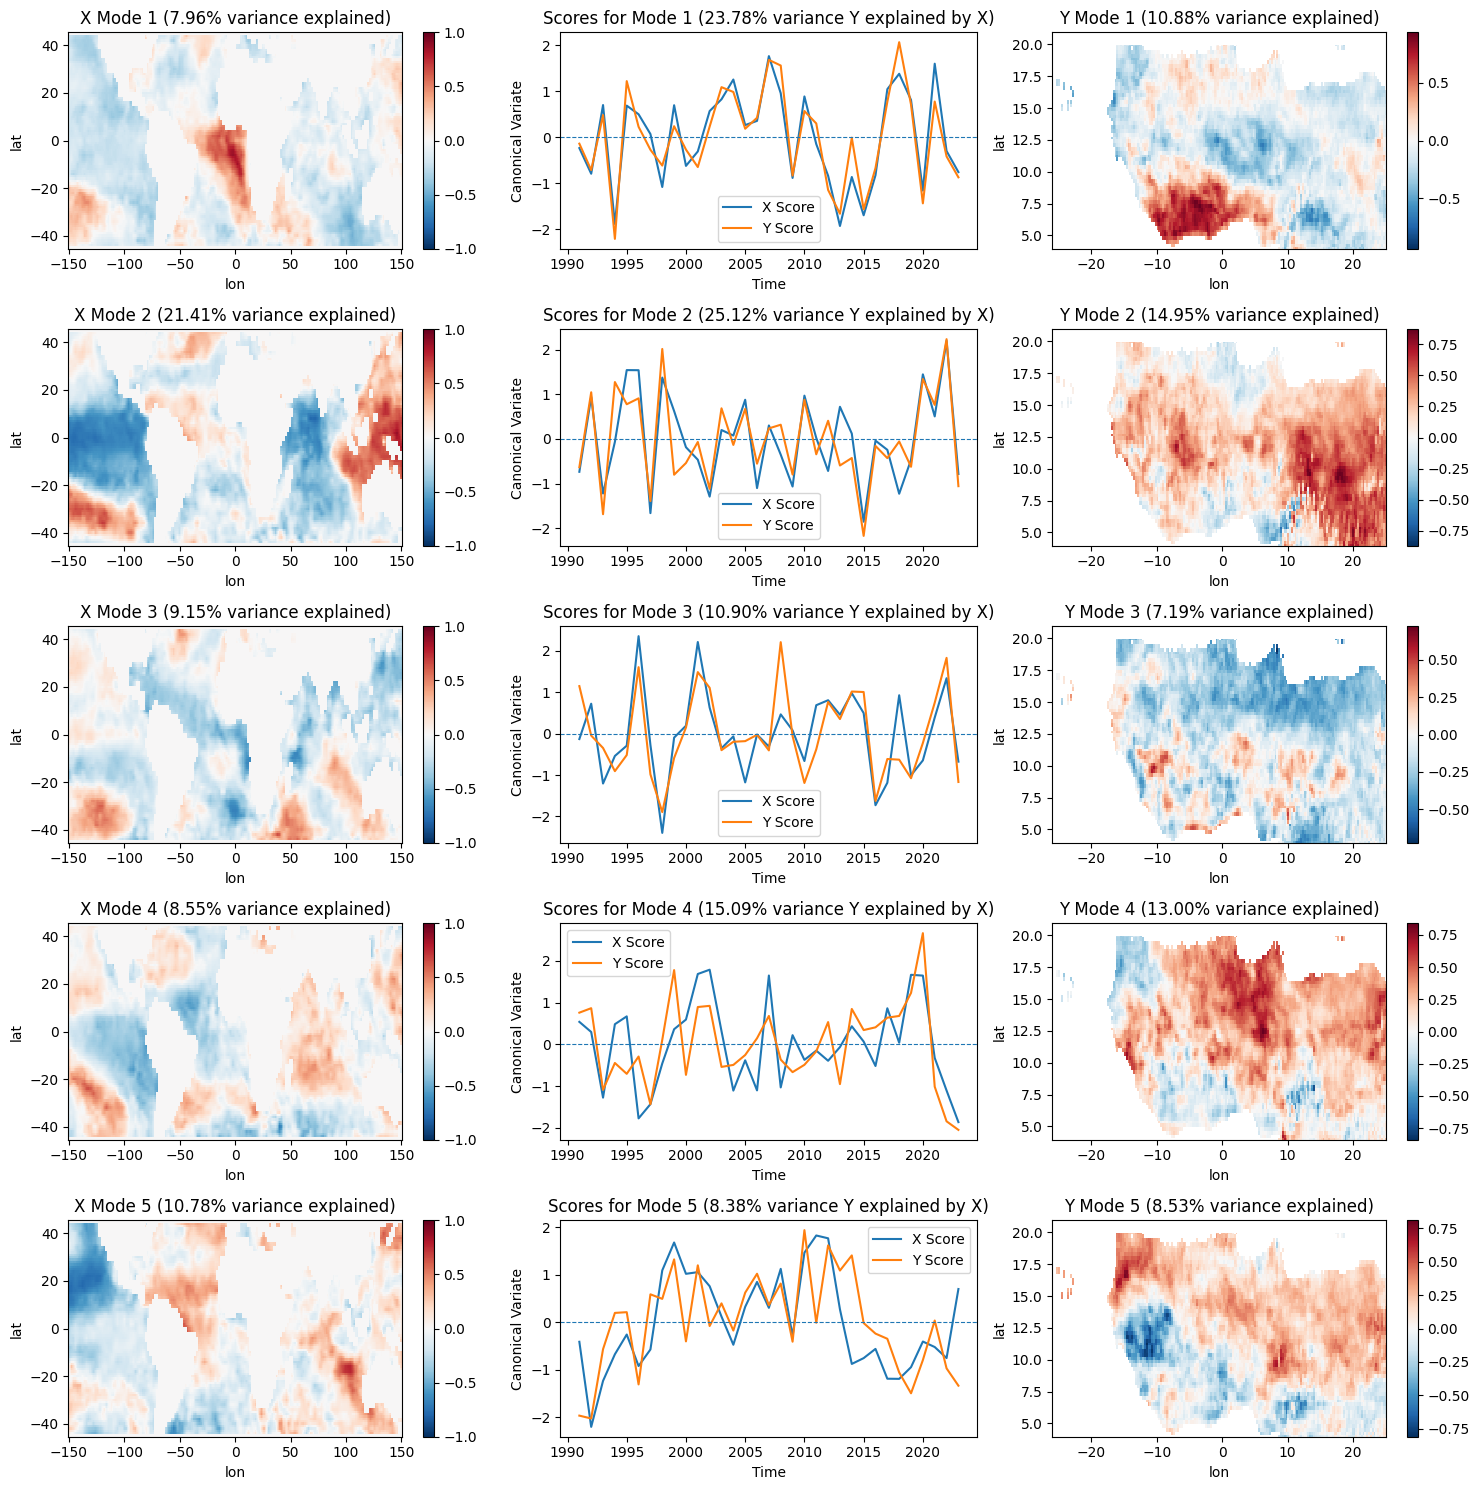

In [66]:
was_cca_.plot_cca_results(X=predictor_f, Y=rainfall , clim_year_start=clim_year_start, clim_year_end=clim_year_end)

In [67]:
predictor_f['T'] = rainfall['T']
if dist_method=="bestfit":
    hindcast_det_cca, hindcast_prob_cca = was_cv.cross_validate(was_cca_, rainfall, predictor_f, clim_year_start, clim_year_end, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    hindcast_det_cca, hindcast_prob_cca = was_cv.cross_validate(was_cca_, rainfall, predictor_f, clim_year_start, clim_year_end)
hdcst_consolidated['CCA_ERSST'] = hindcast_det_cca.sel(T=slice(str(year_start_model),str(year_end_model)))
hdcst_consolidated_prob['CCA_ERSST'] = hindcast_prob_cca.sel(T=slice(str(year_start_model),str(year_end_model)))

Cross-validation ongoing


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33/33 [00:38<00:00,  1.15s/it]


[3.25520915e-05 4.34845421e-05 4.34845421e-05 ... 9.98673908e-01
 9.98673908e-01            nan]


### Verification

In [68]:
score = ['Pearson','MAE']
# model_name = "Obs-Lag"

###### Deterministic

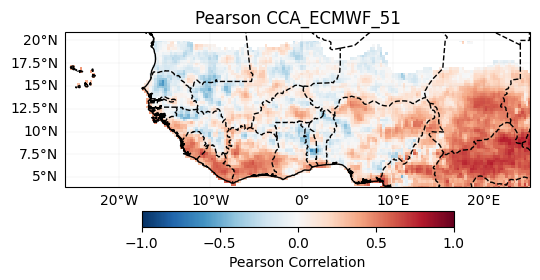

KeyError: 'Pearson'

In [69]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall,
        hindcast_det_cca
    )
    scores_consolidated[i] = {'CCA_ERSST': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

###### Probabilistic

In [ ]:
score = ['GROC','RPSS']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
hindcast_prob_obsBased_all = {}
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall,
        hindcast_prob_cca,
        clim_year_start,
        clim_year_end)
    scores_consolidated[i] = {'CCA_ERSST': r}      
    was_verify.plot_model_score(r, i, dir_save_score, model_name)
    scores_consolidated[i]['CCA_ERSST'] = r

### Forecast

In [ ]:
f_predictors = predictor.isel(T=[-1])
f_predictors['T'] = forecast_det_gcm['T']
if dist_method=="bestfit":
    forecast_det_cca, forecast_prob_cca = was_cca_.forecast(rainfall, clim_year_start, clim_year_end, predictor_f, hindcast_det_cca, f_predictors, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    forecast_det_cca, forecast_prob_cca = was_cca_.forecast(rainfall, clim_year_start, clim_year_end, predictor_f, hindcast_det_cca, f_predictors)    
fcst_consolidated['CCA_ERSST'] = forecast_det_cca
fcst_consolidated_prob['CCA_ERSST'] = forecast_prob_cca
plot_prob_forecasts(f"{dir_to_forecast}/{model_name}{season_str}_{forecast}_Ic_{calendar.month_name[int(month_of_initialization)]}.png", forecast_prob_cca.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast} Initial conditions of {calendar.month_name[int(month_of_initialization)]}",
                    hspace=-0.6, labels=fcst_labels,
                    reverse_cmap=False)

# 4th - Analog-based seasonal forecast

## Analog bias_based

In [70]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
model = WAS_Analog(
    dir_to_save=f"{dir_s2s}/analog",
    year_start=1990,
    year_forecast=2024,          # target forecast year
    month_of_initialization=3,   # May initialisation
    predictor_vars=[{'reanalysis_name': 'ERA5', 'model_name': 'ECMWF_51', 'variable': 'SST', 'area': [40, -180, -35, 100]},
                    # {'reanalysis_name': 'ERA5', 'model_name': 'NCEP_2', 'variable': 'SLP', 'area': [80, -60, -80, 60]},
                    # {'reanalysis_name': 'ERA5', 'model_name': 'NCEP_2', 'variable': 'VGRD_850', 'area': [30, -45, -20, 15]}
                   ],
    method_analog="bias_based",
    standardize=True,
    rolling=3,
    lead_time=[1,2,3],
    clim_year_start=clim_year_start, 
    clim_year_end=clim_year_end,
    dist_method=dist_method
)

#### Cross-validation

In [72]:
was_analog_cv = WAS_Cross_Validator(n_splits=len(rainfall.get_index("T")), nb_omit=2)

In [73]:
if dist_method=="bestfit":
    hindcast_analog_det, hindcast_analog_prob = was_analog_cv.cross_validate(model, rainfall, clim_year_start=clim_year_start, clim_year_end=clim_year_end, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    hindcast_analog_det, hindcast_analog_prob = was_analog_cv.cross_validate(model, rainfall, clim_year_start=clim_year_start, clim_year_end=clim_year_end)    
hdcst_consolidated['fourth.approach'] = hindcast_analog_det.sel(T=slice(str(year_start_model),str(year_end_model)))
hdcst_consolidated_prob['fourth.approach'] = hindcast_analog_prob.sel(T=slice(str(year_start_model),str(year_end_model)))

Cross-validation ongoing


  0%|                                                                                                                              | 0/33 [00:00<?, ?it/s]

PRCP_JAS_2024_ic_4/analog/NOAA_SST_1990_2024_JanFebMarAprMayJunJulAugSepOctNovDec_40-180-35100.nc exists. Skipping download.
Forecast file PRCP_JAS_2024_ic_4/analog/forecast_ecmwf51_SST_2024_MarIc_AprMayJun_1_40-180-35100.nc exists. Skipping download.
Hindcast file PRCP_JAS_2024_ic_4/analog/hindcast_ecmwf51_SST_1994_2016MarIc_AprMayJun_1_40-180-35100.nc exists. Skipping download.
Processing variables: ['SST']
Applied rolling mean with window size 3 for SST.
Standardizing timeseries for SST.


  3%|███▌                                                                                                                  | 1/33 [00:08<04:28,  8.40s/it]

Similar years for 1991: [2002 2005]
PRCP_JAS_2024_ic_4/analog/NOAA_SST_1990_2024_JanFebMarAprMayJunJulAugSepOctNovDec_40-180-35100.nc exists. Skipping download.
Forecast file PRCP_JAS_2024_ic_4/analog/forecast_ecmwf51_SST_2024_MarIc_AprMayJun_1_40-180-35100.nc exists. Skipping download.
Hindcast file PRCP_JAS_2024_ic_4/analog/hindcast_ecmwf51_SST_1994_2016MarIc_AprMayJun_1_40-180-35100.nc exists. Skipping download.
Processing variables: ['SST']
Applied rolling mean with window size 3 for SST.
Standardizing timeseries for SST.


...

Similar years for 2021: [2018 2006]
PRCP_JAS_2024_ic_4/analog/NOAA_SST_1990_2024_JanFebMarAprMayJunJulAugSepOctNovDec_40-180-35100.nc exists. Skipping download.
Forecast file PRCP_JAS_2024_ic_4/analog/forecast_ecmwf51_SST_2024_MarIc_AprMayJun_1_40-180-35100.nc exists. Skipping download.
Hindcast file PRCP_JAS_2024_ic_4/analog/hindcast_ecmwf51_SST_1994_2016MarIc_AprMayJun_1_40-180-35100.nc exists. Skipping download.
Processing variables: ['SST']
Applied rolling mean with window size 3 for SST.
Standardizing timeseries for SST.


 97%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍   | 32/33 [04:47<00:08,  8.71s/it]

Similar years for 2022: [2014 2007]
PRCP_JAS_2024_ic_4/analog/NOAA_SST_1990_2024_JanFebMarAprMayJunJulAugSepOctNovDec_40-180-35100.nc exists. Skipping download.
Forecast file PRCP_JAS_2024_ic_4/analog/forecast_ecmwf51_SST_2024_MarIc_AprMayJun_1_40-180-35100.nc exists. Skipping download.
Hindcast file PRCP_JAS_2024_ic_4/analog/hindcast_ecmwf51_SST_1994_2016MarIc_AprMayJun_1_40-180-35100.nc exists. Skipping download.
Processing variables: ['SST']
Applied rolling mean with window size 3 for SST.
Standardizing timeseries for SST.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33/33 [04:56<00:00,  8.97s/it]

Similar years for 2023: [2012 2009]


#### Verification

###### Deterministic

In [ ]:
score = ['Pearson','MAE']
model_name = "Analogue-Based Forecasting"

In [ ]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall,
        hindcast_analog_det
    )
    scores_consolidated[i] = {'fourth.approach': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

###### Probabilistic

In [ ]:
score = ['GROC', 'RPSS']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall,
        hindcast_analog_prob,
        clim_year_start,
        clim_year_end)
    scores_consolidated[i] = {'fourth.approach': r}
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

#### Forecast

In [ ]:
## Analysis SST evolution
model.composite_plot(rainfall, clim_year_start, clim_year_end, 
                     hindcast_analog_det, plot_predictor=True,
                    variable="SST", best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)

In [ ]:
## Plot silimar years behavior
model.composite_plot(rainfall, clim_year_start, clim_year_end, hindcast_analog_det, plot_predictor=False, best_code_da=best_code_da,
                     best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)

In [ ]:
if dist_method=="bestfit":
    similar_years, forecast_det_analog, forecast_prob_analog = model.forecast(rainfall, clim_year_start, clim_year_end, hindcast_analog_det, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
else:
    similar_years, forecast_det_analog, forecast_prob_analog = model.forecast(rainfall, clim_year_start, clim_year_end, hindcast_analog_det)    
fcst_consolidated['fourth.approach'] = forecast_det_analog
fcst_consolidated_prob['fourth.approach'] = forecast_prob_analog
plot_prob_forecasts(f"{dir_to_forecast}/{model_name}{season_str}_{forecast}_Ic_{calendar.month_name[int(month_of_initialization)]}.png", forecast_prob_analog.drop_vars('T').squeeze(), f"{model_name} {season_str}-{forecast} Initial conditions of {calendar.month_name[int(month_of_initialization)]}",
                    hspace=-0.6, labels=fcst_labels,
                    reverse_cmap=False)

# Consolidated Forecasts

In [ ]:
best_models = list(hdcst_consolidated.keys())
best_models 

#### Cross-validation

In [ ]:
all_model_hdcst, all_model_fcst, obs, best_score = process_datasets_for_mme(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),hdcsted=hdcst_consolidated, fcsted=fcst_consolidated, gcm=False, ELM_ELR=False,  Prob=False, best_models=best_models, scores=scores_consolidated, model=False, score_metric="GROC")

In [ ]:
was_mme = WAS_mme_Weighted(equal_weighted=False, dist_method=dist_method, metric="GROC", threshold=0.6)

In [ ]:
hindcast_det, forecast_det  = was_mme.compute(obs, all_model_hdcst, all_model_fcst, best_score, complete=True)
hindcast_prob = was_mme.compute_prob(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, hindcast_det, best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)

#### Verification

###### Deterministic

In [ ]:
score = ['Pearson','MAE']
model_name = "Consolidated Forecast"

In [ ]:
for i in score:
    r = was_verify.compute_deterministic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_det
    )
    r = r + 0.1
    # r.to_dataset(name="Equaly weigthed")
    # r.to_netcdf(f"./equaly_{i}.nc")
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

###### Probabilistic

In [ ]:
score = ['GROC', 'RPSS']

In [ ]:
score = score.append('GROC') if 'GROC' not in score else score
for i in score:
    print(was_verify.scores[i][0])
    r = was_verify.compute_probabilistic_score(
        was_verify.get_scores_metadata()[i][5],
        rainfall.sel(T=slice(str(year_start_model),str(year_end_model))),
        hindcast_prob,
        clim_year_start,
        clim_year_end)
    r = r + 0.1
    # r.to_dataset(name="Equaly weigthed")
    # r.to_netcdf(f"./equaly_{i}.nc")
    was_verify.plot_model_score(r, i, dir_save_score, model_name)

### Forecast

In [ ]:
_,forecast_prob = was_mme.forecast(rainfall.sel(T=slice(str(year_start_model),str(year_end_model))), clim_year_start, clim_year_end, hindcast_det, forecast_det,best_code_da=best_code_da, best_shape_da=best_shape_da, best_loc_da=best_loc_da, best_scale_da=best_scale_da)
plot_prob_forecasts(dir_to_forecast, forecast_prob.drop_vars('T').squeeze(),
                    f"{model_name} {season_str}-{forecast}" ,#issued {datetime.datetime.today().strftime("%Y-%m-%d")}", 
                    reverse_cmap=False,  hspace=-0.6, labels=fcst_labels) # logo=logopath, logo_size=0.1,
gc.collect()

In [ ]:
forecast_det.to_netcdf(f'{dir_to_forecast}/Forecast_Det_PRCP{season_str}_{forecast}.nc')

In [ ]:
forecast_prob.to_netcdf(f'{dir_to_forecast}/Forecast_Prob_PRCP{season_str}_{forecast}.nc')

In [ ]:
!jupyter nbconvert --to html --no-input ./Template_seasonal_Good.ipynb

In [ ]:
# Filter model names to identify precipitation-related models
variables_reanalysis = ["ERA5.SST"] #[key for key in downloader.ReanalysisName().keys() if "SST" in key]# or "VGRD_850" in key]

# Specify the directory to save downloaded model data
dir_to_save_Reanalysis = f"{dir_s2s}/reanalysis_data/"

# choose sequence corresponding to seasonal forecast targets (JAS season in this case)
season = ["06", "07", "08"]  # Jan-Feb-Mar forecast period

# Define the observation period (years 1993 to 2016)
year_start = 1991
year_end = 2024

# Set the bounding box for the area of interest (latitude and longitude bounds)
extent = [60, -180, -60, 180]  # [Northern, Western, Southern and Eastern] 

# Specify whether to overwrite existing files when downloading data
force_download = False

In [ ]:
downloader.WAS_Download_Reanalysis(
    dir_to_save_Reanalysis,
    variables_reanalysis,
    year_start,
    year_end,
    extent,
    season, 
    force_download
)

In [ ]:
zones_for_PCR = {'A': ('A', -150, 150, -45, 45)}

In [ ]:
plot_map([extent[1],extent[3],extent[2],extent[0]], sst_indices = zones_for_PCR, title="Predictors Area",fig_size=(8,6))

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

paths = {
    "Jun": "PRCP_JAS_2024_ic_4/reanalysis_data/NOAA_SST_1991_2024_Jun.nc",
    "Jul": "PRCP_JAS_2024_ic_4/reanalysis_data/NOAA_SST_1991_2024_Jul.nc",
    "Aug": "PRCP_JAS_2024_ic_4/reanalysis_data/NOAA_SST_1991_2024_Aug.nc",
    "JJA": "PRCP_JAS_2024_ic_4/reanalysis_data/NOAA_SST_1991_2024_JunJulAug.nc",
}

def clim_anom(ds, var="sst", clim_start=1991, clim_end=2020, target_year=2024):
    da = ds[var]
    years = da["T"].dt.year
    clim = da.sel(T=(years >= clim_start) & (years <= clim_end)).mean("T", skipna=True)
    targ = da.sel(T=(years == target_year)).squeeze("T", drop=True)
    return targ - clim - 0.2

anom = {}
for k, p in paths.items():
    ds = xr.open_dataset(p)
    anom[k] = clim_anom(ds)

titles = {
    "Jun": "June 2024 SST anomaly (vs 1991–2020)",
    "Jul": "July 2024 SST anomaly (vs 1991–2020)",
    "Aug": "August 2024 SST anomaly (vs 1991–2020)",
    "JJA": "JJA 2024 SST anomaly (vs 1991–2020)",
}

# --- Crop domain: Tropical Atlantic / West Africa sector ---
# Adjust if you want tighter/looser framing
extent = [-80, 30, -20, 30]  # [lon_min, lon_max, lat_min, lat_max]

# --- Common symmetric color scale across all panels (good for anomalies) ---
all_vals = xr.concat([anom[k] for k in ["Jun", "Jul", "Aug", "JJA"]], dim="panel")
# robust symmetric limits (2–98% to avoid outliers)
lo = float(all_vals.quantile(0.02, skipna=True))
hi = float(all_vals.quantile(0.98, skipna=True))
a = max(abs(lo), abs(hi))
vmin, vmax = -a, a

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2, 2, figsize=(12, 7),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

mappables = []

for ax, key in zip(axes.ravel(), ["Jun", "Jul", "Aug", "JJA"]):
    ax.set_extent(extent, crs=proj)
    ax.coastlines(linewidth=0.6)

    m = anom[key].plot.pcolormesh(
        ax=ax,
        transform=proj,
        x="X", y="Y",
        cmap="RdBu_r",
        vmin=vmin, vmax=vmax,
        add_colorbar=False
    )
    ax.set_title(titles[key])
    mappables.append(m)

# --- Shared colorbar ---
cbar = fig.colorbar(
    mappables[0], ax=axes,
    orientation="horizontal",
    pad=0.06, fraction=0.05, shrink=0.95
)
cbar.set_label("SST anomaly (°C) relative to 1991–2020")

out_png = "PRCP_JAS_2024_ic_4/reanalysis_data/NOAA_SST_anomalies_2024.png"
fig.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)